## Import Modules

In [6]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# RESULTS_DIR = "/kaggle/working/model_results"
# os.makedirs(RESULTS_DIR, exist_ok=True)


# TUNING_DIR = "/kaggle/working/tuning_results"
# os.makedirs(TUNING_DIR, exist_ok=True)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# OUTPUT_DIR = "/kaggle/working/figures_preprocessing"
# os.makedirs(OUTPUT_DIR, exist_ok=True)


# def find_file(filename, base_path="/input"):
#     for root, dirs, files in os.walk(base_path):
#         if filename in files:
#             return os.path.join(root, filename)
#     raise FileNotFoundError(f"File {filename} was not found in {base_path}")


train_path = "data/train.csv"
test_path = "data/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (22750, 9)
Test shape: (12250, 8)


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


# Breakdown of features in training dataset:

The dataset consists of 9 columns:

* **Employee ID**: The unique ID allocated for each employee.
* **Date of Joining**: The date-time when the employee has joined the organization.
* **Gender**: The gender of the employee (Male/Female)
* **Company Type**: The type of company where the employee is working (Service/Product)
* **WFH Setup Available**: Is "work from home" available for the employee (Yes/No)
* **Designation*: The designation of the employee of work in the organization.
In the range of [0.0, 5.0] bigger is higher designation.
* **Resource Allocation**: The amount of resource allocated to the employee to work, i.e., number of working hours.
In the range of [1.0, 10.0] (higher means more resource)
* **Mental Fatigue Score**: The level of fatigue the employee is facing mentally.
In the range of [0.0, 10.0] where 0.0 means no fatigue and 10.0 means completely burnt out.
* **Burn Rate**: The value we aim to predict for each employee telling the rate of burn out while working.
In the range of [0.0, 1.0] where the higher the value is more is the burn out.

In [10]:
# Start by cleaning up column names, converting them to snake_case.

def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df


train_df = clean_column_names(train_df)
test_df = clean_column_names(test_df)

train_df.head()

,employee_id,date_of_joining,gender,company_type,wfh_setup_available,designation,resource_allocation,mental_fatigue_score,burn_rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [14]:
print("Information about train_df:")
train_df.info()

print("\nDescription of numerical features:")
display(train_df.describe())

print("\nNumber of Unique Values:")
display(train_df.nunique().sort_values())

Information about train_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           22750 non-null  object 
 1   date_of_joining       22750 non-null  object 
 2   gender                22750 non-null  object 
 3   company_type          22750 non-null  object 
 4   wfh_setup_available   22750 non-null  object 
 5   designation           22750 non-null  float64
 6   resource_allocation   21369 non-null  float64
 7   mental_fatigue_score  20633 non-null  float64
 8   burn_rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB

Description of numerical features:


,designation,resource_allocation,mental_fatigue_score,burn_rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000



Number of Unique Values:


company_type                2
gender                      2
wfh_setup_available         2
designation                 6
resource_allocation        10
mental_fatigue_score      101
burn_rate                 101
date_of_joining           366
employee_id             22750
dtype: int64

## Missing Values Analysis
Before proceding it's crucial to get a handle on how much data is missing, and from which features (columns).

In [15]:
miss_val_table = pd.DataFrame({
    "missing_count": train_df.isna().sum(),
    "missing_percent": (train_df.isna().mean() * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

display(miss_val_table)

,missing_count,missing_percent
mental_fatigue_score,2117,9.31
resource_allocation,1381,6.07
burn_rate,1124,4.94
employee_id,0,0.00
date_of_joining,0,0.00
wfh_setup_available,0,0.00
company_type,0,0.00
gender,0,0.00
designation,0,0.00


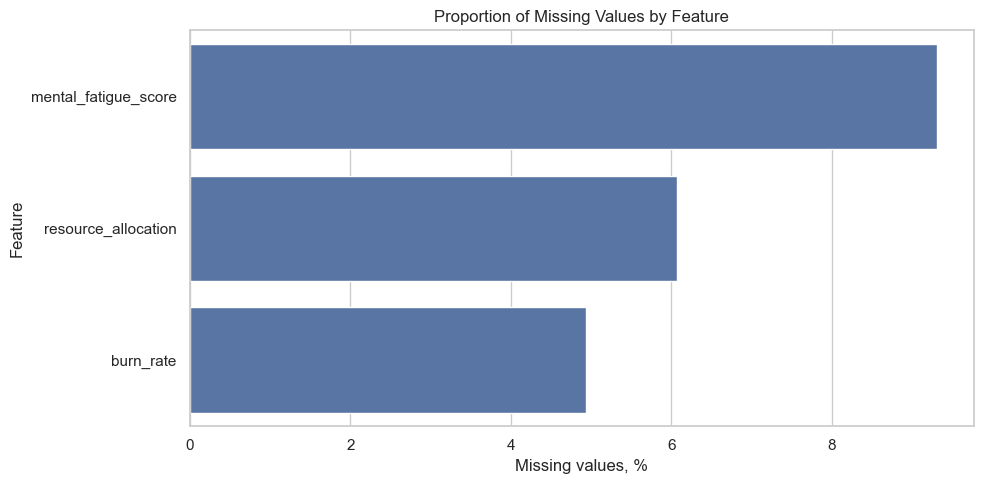

In [17]:
missing_percent = train_df.isna().mean().sort_values(ascending=False) * 100
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_percent.values, y=missing_percent.index)
plt.title("Proportion of Missing Values by Feature")
plt.xlabel("Missing values, %")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(f"output/fig_2_1_missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

## Drop Irrelevant Columns (Features)

In [18]:
columns_to_drop = ["employee_id", "date_of_joining"]

train_df = train_df.drop(columns=columns_to_drop, errors="ignore")
test_df = test_df.drop(columns=columns_to_drop, errors="ignore")

print(train_df.columns.tolist())

['gender', 'company_type', 'wfh_setup_available', 'designation', 'resource_allocation', 'mental_fatigue_score', 'burn_rate']


## Remove rows without target value

In [19]:
target_col = "burn_rate"

print("Number of rows before removing missing-target-variable rows:", train_df.shape[0])

train_df = train_df.dropna(subset=[target_col]).copy()

print("Number of rows after removing missing-target-variable rows:", train_df.shape[0])

Number of rows before removing missing-target-variable rows: 22750
Number of rows after removing missing-target-variable rows: 21626


## Analysis of the distribution of a variable

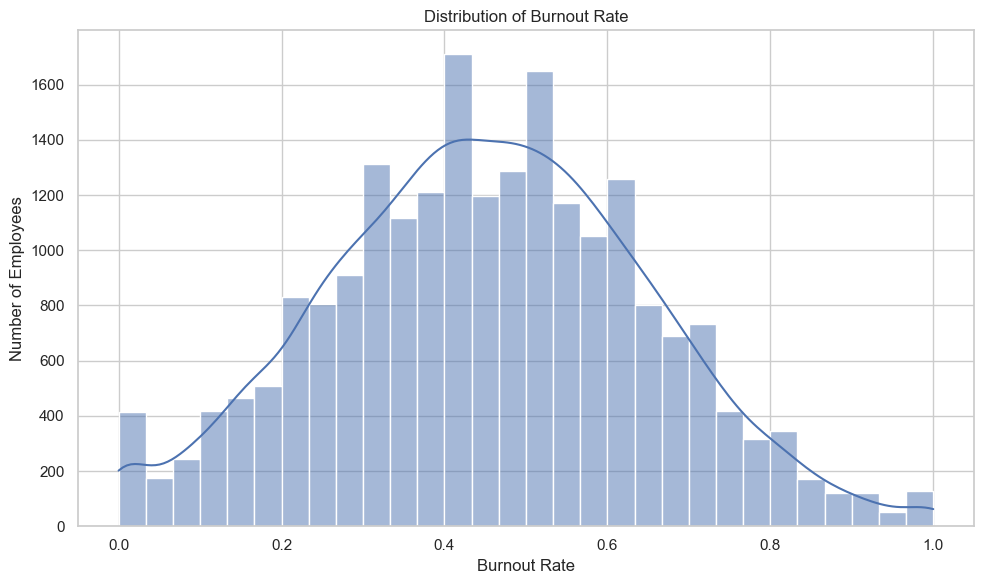

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df[target_col], bins=30, kde=True)
plt.title("Distribution of Burnout Rate")
plt.xlabel("Burnout Rate")
plt.ylabel("Number of Employees")
plt.tight_layout()

plt.savefig(f"output/fig_2_2_burnout_rate_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Classification of burnout risk levels

In [23]:
def create_burnout_class(value):
    if value < 0.33:
        return "Low"
    elif value < 0.66:
        return "Medium"
    else:
        return "High"


train_df["burnout_level"] = train_df[target_col].apply(create_burnout_class)

display(train_df[["burn_rate", "burnout_level"]].head())
display(train_df["burnout_level"].value_counts())

,burn_rate,burnout_level
0,0.16,Low
1,0.36,Medium
2,0.49,Medium
3,0.20,Low
4,0.52,Medium


burnout_level
Medium    12551
Low        5726
High       3349
Name: count, dtype: int64

## Distribution of burnout risk levels:

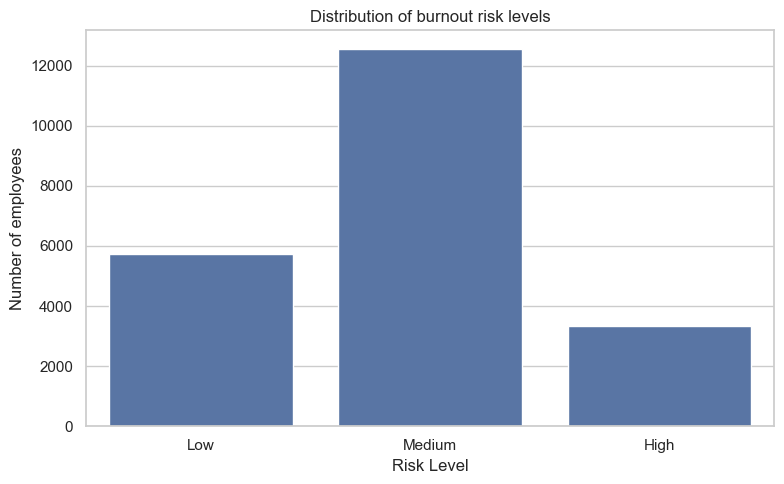

In [26]:
plt.figure(figsize=(8, 5))
order = ["Low", "Medium", "High"]

sns.countplot(data=train_df, x="burnout_level", order=order)
plt.title("Distribution of burnout risk levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of employees")
plt.tight_layout()

plt.savefig(f"output/fig_2_3_burnout_level_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Numerical Feature Analysis

In [27]:
num_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical Features:")
print(num_cols)

display(train_df[num_cols].describe())

Numerical Features:
['designation', 'resource_allocation', 'mental_fatigue_score', 'burn_rate']


,designation,resource_allocation,mental_fatigue_score,burn_rate
count,21626.000000,20348.000000,19681.000000,21626.000000
mean,2.178766,4.483831,5.729851,0.452005
std,1.135428,2.048170,1.920784,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


## Correlation Matrix of Numerical Features

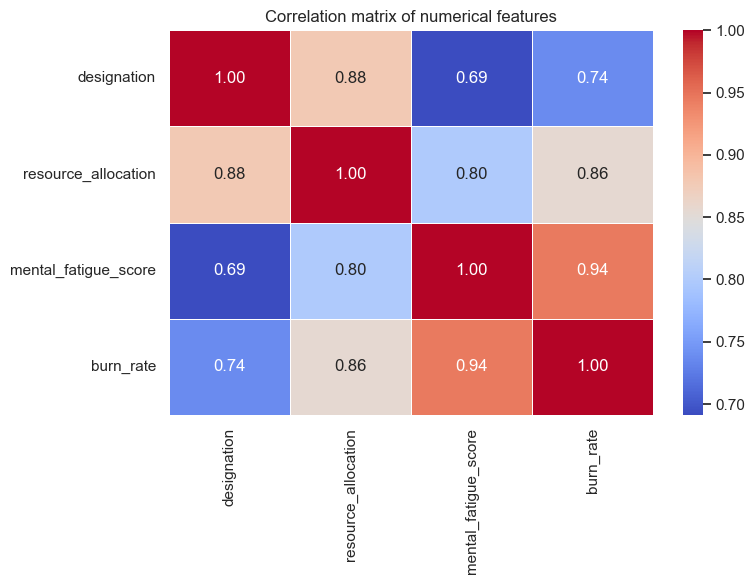

In [28]:
corr_matrix = train_df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix of numerical features")
plt.tight_layout()

plt.savefig(f"output/fig_2_4_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()